<a href="https://colab.research.google.com/github/zeynep-serra/ML_Notes/blob/main/ReinforcementLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# reinforcement learning
# t -> t+1
# reward & punishment, trial & error

# multi armed bandit problem

# upper confidence bound UCB algo.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
data = pd.read_csv('ads_2.csv')
data.head()

,Ad 1,Ad 2,Ad 3,Ad 4,Ad 5,Ad 6,Ad 7,Ad 8,Ad 9,Ad 10
0,1,0,0,0,1,0,0,0,1,0
1,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0


In [ ]:
# at each round n, we consider 2 numbers for each ad i
# Ni(n): num of times ad i selected up to round n
# Ri(n): sum of rewards of ad i up to round n
# avg reward of ad i : Ri(n) / Ni(n)
# confidence interval at round n: (3log(n) / 2Ni(n)) ** 0.5
# select the ad that has max UCB (avg + ci)
import math

N = 10000 # num of users / rounds
d = 10 # num of ads
ads_selected = [] # 10000
numbers_of_selections = [0] * d
sums_of_reward = [0] * d
total_reward = 0 # sum of rewards received each round

for n in range(0, N):
  ad = 0
  max_upper_bound = 0

  for i in range(0, d):
    if (numbers_of_selections[i] > 0):
      average_reward = sums_of_reward[i] / numbers_of_selections[i]
      delta_i = math.sqrt(3/2 * math.log(n + 1) / numbers_of_selections[i])
      upper_bound = average_reward + delta_i
    else:
      upper_bound = 1e400
    if upper_bound > max_upper_bound:
      max_upper_bound = upper_bound
      ad = i

  ads_selected.append(ad)
  numbers_of_selections[ad] = numbers_of_selections[ad] + 1
  reward = data.values[n, ad]
  sums_of_reward[ad] = sums_of_reward[ad] + reward
  total_reward = total_reward + reward

(array([ 705.,  387.,  186.,  345., 6323.,  150.,  292., 1170.,  256.,
         186.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

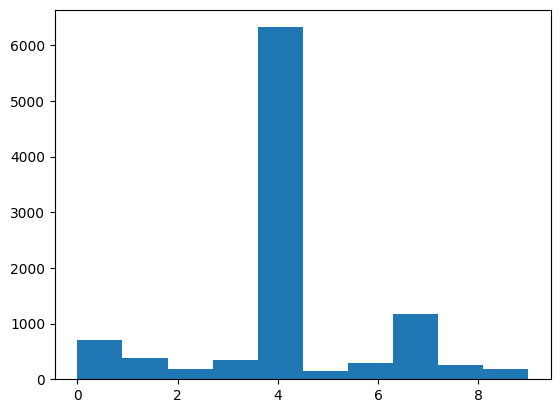

In [ ]:
plt.hist(ads_selected)

In [ ]:
# thompson sampling
# ucb is deterministic, requires update every round & thompson is probabilistic

# Ni1
# Ni0
# for each ad i, take random draw from distribution beta
import random
N = 10000
d = 10
ads_selected = []
numbers_of_rewards_1 = [0] * d
numbers_of_rewards_0 = [0] * d
total_reward = 0

for n in range(0, N):
  ad = 0
  max_random = 0

  for i in range(0, d):
    random_beta = random.betavariate(numbers_of_rewards_1[i] + 1, numbers_of_rewards_0[i] + 1)
    if random_beta > max_random:
      max_random = random_beta
      ad = i

  ads_selected.append(ad)
  reward = data.values[n, ad]
  if reward == 1:
    numbers_of_rewards_1[ad] = numbers_of_rewards_1[ad] + 1
  else:
    numbers_of_rewards_0[ad] = numbers_of_rewards_0[ad] + 1
  total_reward = total_reward + reward

(array([ 102.,   71.,   59.,  133., 9351.,   26.,   32.,  143.,   45.,
          38.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

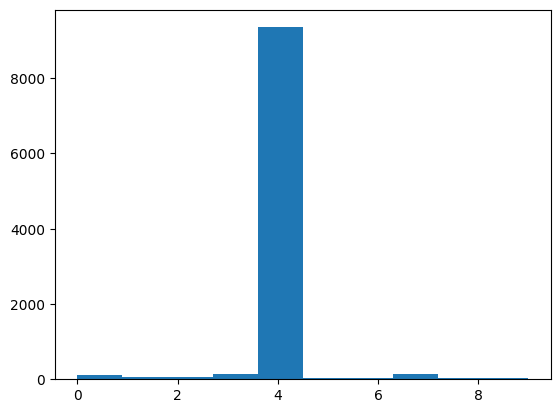

In [ ]:
plt.hist(ads_selected)